![Machine Learning Pipeline for Credit Risk Analysis](Banner_ML.png)

# Machine learning workflow: 
From Exploratory data analysis and Preprocessing to Model implementation, evaluation, and result interpretation. 

## Loading and Inspecting datasets

Import the required libraries and inspect the three datasets before analysis.

In [1]:
#importing libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,recall_score,precision_score,f1_score
from sklearn.model_selection import train_test_split, GridSearchCV, ParameterGrid
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_selection import SelectKBest,f_classif



wine_df = pd.read_csv("wine.csv")
chickwts_df = pd.read_csv("chickwts.csv")
arrests_df = pd.read_csv("USArrests.csv")

print(wine_df.head())
print(chickwts_df.head())
print(arrests_df.head())



   Wine  Alcohol  Malic.acid   Ash   Acl   Mg  Phenols  Flavanoids  \
0     1    14.23        1.71  2.43  15.6  127     2.80        3.06   
1     1    13.20        1.78  2.14  11.2  100     2.65        2.76   
2     1    13.16        2.36  2.67  18.6  101     2.80        3.24   
3     1    14.37        1.95  2.50  16.8  113     3.85        3.49   
4     1    13.24        2.59  2.87  21.0  118     2.80        2.69   

   Nonflavanoid.phenols  Proanth  Color.int   Hue    OD  Proline  
0                  0.28     2.29       5.64  1.04  3.92     1065  
1                  0.26     1.28       4.38  1.05  3.40     1050  
2                  0.30     2.81       5.68  1.03  3.17     1185  
3                  0.24     2.18       7.80  0.86  3.45     1480  
4                  0.39     1.82       4.32  1.04  2.93      735  
   rownames  weight       feed
0         1     179  horsebean
1         2     160  horsebean
2         3     136  horsebean
3         4     227  horsebean
4         5     217  h

In [2]:
#Checikng info for the datasets and dataset sizes
print(wine_df.info())

print(chickwts_df.info())

print(arrests_df.info())



print(f"Wine:",wine_df.shape)
print(f"Chickwts:",chickwts_df.shape)
print(f"Arrests:",arrests_df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
None
<class 'pandas.core.fr

In [3]:
#Summary statistics for the datasets

print(wine_df.describe())

print(chickwts_df.describe())

print(arrests_df.describe())

             Wine     Alcohol  Malic.acid         Ash         Acl          Mg  \
count  178.000000  178.000000  178.000000  178.000000  178.000000  178.000000   
mean     1.938202   13.000618    2.336348    2.366517   19.494944   99.741573   
std      0.775035    0.811827    1.117146    0.274344    3.339564   14.282484   
min      1.000000   11.030000    0.740000    1.360000   10.600000   70.000000   
25%      1.000000   12.362500    1.602500    2.210000   17.200000   88.000000   
50%      2.000000   13.050000    1.865000    2.360000   19.500000   98.000000   
75%      3.000000   13.677500    3.082500    2.557500   21.500000  107.000000   
max      3.000000   14.830000    5.800000    3.230000   30.000000  162.000000   

          Phenols  Flavanoids  Nonflavanoid.phenols     Proanth   Color.int  \
count  178.000000  178.000000            178.000000  178.000000  178.000000   
mean     2.295112    2.029270              0.361854    1.590899    5.058090   
std      0.625851    0.998859    

In [4]:
#Checking for missing values
print(wine_df.isna().sum())

print(chickwts_df.isna().sum())

print(arrests_df.isna().sum())

Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64
rownames    0
weight      0
feed        0
dtype: int64
Murder      0
Assault     0
UrbanPop    0
Rape        0
State       0
dtype: int64


In [5]:
print(wine_df.duplicated().sum())

print(chickwts_df.duplicated().sum())

print(arrests_df.duplicated().sum())

0
0
0


## PREPARATION OF WINE DATASET

In [6]:
wine_df['Wine'].unique()

array([1, 2, 3])

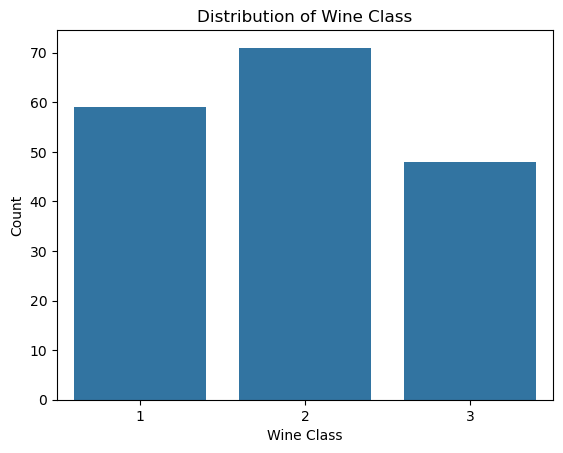

In [7]:
# A barchart to help us know distribution of the target variable in the wine dataset
wine_target = 'Wine'

X_wine = wine_df.drop(columns=[wine_target])
y_wine= wine_df[wine_target]

sns.countplot(data=wine_df,x='Wine')
plt.xlabel('Wine Class')
plt.ylabel('Count')
plt.title('Distribution of Wine Class')
plt.show()

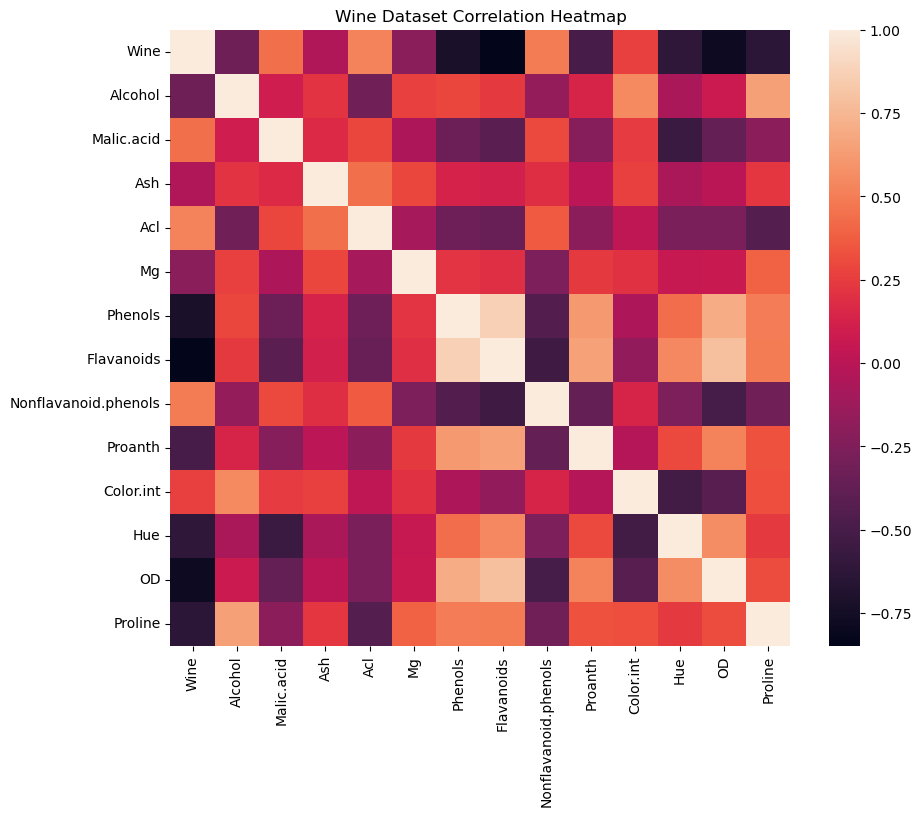

In [8]:
#A correlation heatmap to help visualize the  relationships between the numerical features in the wine dataset
wine_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(wine_df.corr(numeric_only=True))
plt.title('Wine Dataset Correlation Heatmap')
plt.show()

## 1. Define Features and Target Variable
Separate the predictor variables (chemical properties) from the target variable (wine class). The target labels are converted into numerical codes to enable machine learning model training.

In [9]:
wine_target = "Wine"

# Features and target
X_wine = wine_df.drop(columns=[wine_target])

# Convert target labels to numeric codes if necessary
y_wine = wine_df[wine_target].astype("category").cat.codes


## 2. Split the Dataset into Training and Testing Sets
Partition the dataset into training and testing subsets. The training set is used for model development, while the testing set is reserved for evaluating model performance on unseen data.

In [10]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_wine,
    y_wine,
    test_size=0.2,
    random_state=42,
    stratify=y_wine
)

## 3. Feature Standardization
Standardize all feature variables to ensure they have a mean of zero and a standard deviation of one. This step is essential for distance-based algorithms such as k-NN.

In [11]:
# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Dimensionality Reduction Using PCA
Apply Principal Component Analysis (PCA) to reduce the number of features while retaining 95% of the original variance. This helps reduce noise, improve computational efficiency, and potentially enhance model performance.

In [12]:
# PCA
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

## 5. Hyperparameter Tuning with Grid Search
Perform an exhaustive search over multiple values of the number of neighbors (*k*) and different distance metrics to determine the optimal k-NN configuration using cross-validation.

In [13]:
# Hyperparameter tuning
param_grid = {
    'n_neighbors': range(1, 21),
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train_pca, y_train)

best_k = grid_search.best_params_['n_neighbors']
best_metric = grid_search.best_params_['metric']

print(f"Best k: {best_k}")
print(f"Best Distance Metric: {best_metric}")

Best k: 18
Best Distance Metric: euclidean


## 6. Train the Final k-NN Classification Model
Build and train the final k-NN classifier using the optimal values obtained during hyperparameter tuning.

In [14]:
# Train final model
knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric=best_metric
)

knn.fit(X_train_pca, y_train)


KNeighborsClassifier(metric='euclidean', n_neighbors=18)

## 7. Generate Predictions
Use the trained model to predict wine classes for observations in the test dataset.

In [15]:
# Predictions
y_pred = knn.predict(X_test_pca)

## 8. Evaluate Model Performance
Assess the effectiveness of the classifier using a classification report and overall accuracy score. Key metrics include precision, recall, F1-score, and accuracy.

In [16]:
# Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Accuracy: 1.0000


## PREPARATION FOR CHICKWTS DATASET

In [17]:
#preparation for chickwts

chickwts_df['feed'].value_counts()

feed
soybean      14
linseed      12
casein       12
sunflower    12
meatmeal     11
horsebean    10
Name: count, dtype: int64

feed
casein       323.583333
horsebean    160.200000
linseed      218.750000
meatmeal     276.909091
soybean      246.428571
sunflower    328.916667
Name: weight, dtype: float64


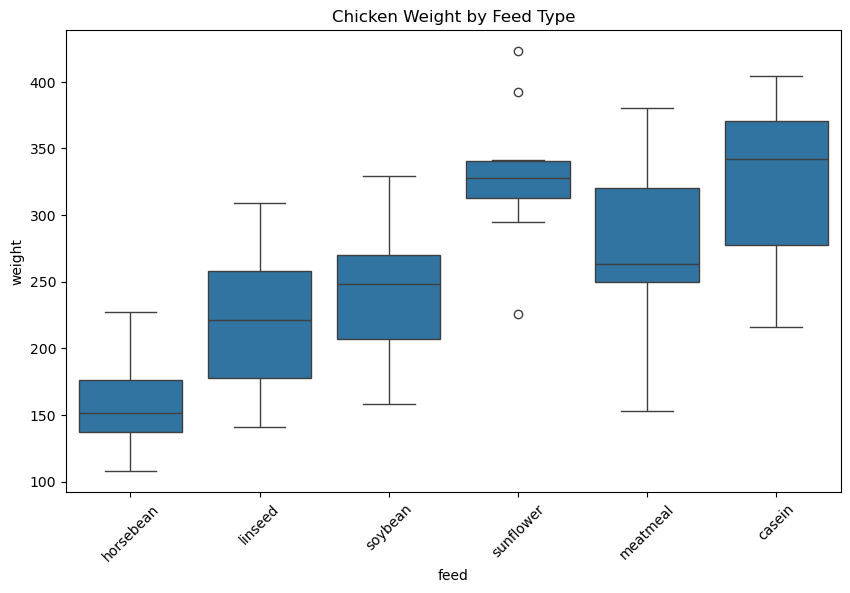

In [18]:
print(chickwts_df.groupby('feed')['weight'].mean())
# A boxplot to visualize the distribution of chicken weights across different feed types
plt.figure(figsize=(10,6))
sns.boxplot(data=chickwts_df,x='feed',y='weight')
plt.title('Chicken Weight by Feed Type')
plt.xticks(rotation=45)
plt.show()



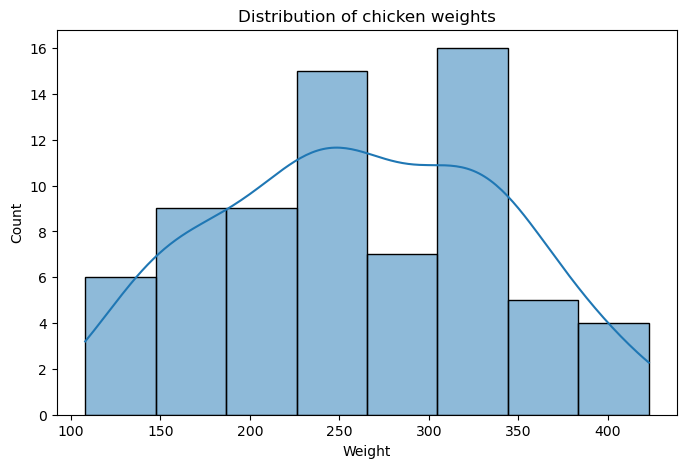

In [19]:
#A histogram to visualize the distribution of chicken weights
plt.figure(figsize=(8,5))
sns.histplot(chickwts_df['weight'],kde=True)
plt.title("Distribution of chicken weights")
plt.xlabel('Weight')
plt.show()

In [20]:
X_chick = chickwts_df['weight']

## Agricultural  Feed Recommendation Engine

In [21]:
# Calculate average weight for each feed type
feed_performance = chickwts_df.groupby('feed')['weight'].mean().reset_index()

feed_performance

,feed,weight
0,casein,323.583333
1,horsebean,160.200000
2,linseed,218.750000
3,meatmeal,276.909091
4,soybean,246.428571
5,sunflower,328.916667


In [22]:
# Standardize the Data
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

X = chickwts_df[['weight']]
scaler = StandardScaler()
chickwts_scaled = scaler.fit_transform(X)

## PCA

In [23]:
pca = PCA(n_components=1)
chickwts_pca = pca.fit_transform(chickwts_scaled)

## similarity matrix

In [24]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarity
similarity_matrix = cosine_similarity(chickwts_pca)

print(similarity_matrix.shape)

(71, 71)


## Recommendation function

In [25]:
def recommend_feeds(feed_name, num_recommendations=3):

    
    # Find the first observation belonging to the selected feed
    feed_index = chickwts_df.index[
        chickwts_df['feed'] == feed_name
    ].tolist()[0]
    
    # Get similarity scores for that observation
    similarity_scores = list(
        enumerate(similarity_matrix[feed_index])
    )
    
    # Sort by similarity from highest to lowest
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )
    
    # Remove the selected observation itself
    similarity_scores = [
        (i, score)
        for i, score in similarity_scores
        if i != feed_index
    ]
    
    # Get the feed names of the most similar observations
    recommended_feeds = [
        chickwts_df.iloc[i]['feed']
        for i, score in similarity_scores[:num_recommendations]
    ]
    
    return recommended_feeds

In [26]:
print(
    "Recommended feeds for 'soybean':",
    recommend_feeds('soybean', 3)
)

Recommended feeds for 'soybean': ['horsebean', 'horsebean', 'horsebean']


## PREPARATION OF USArrests DATASET

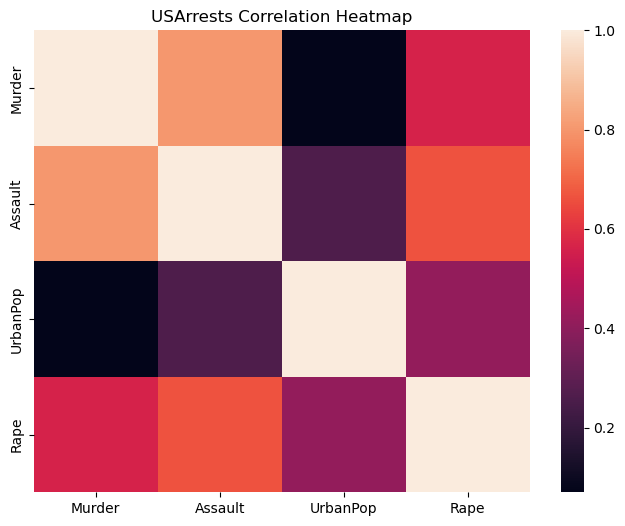

In [27]:
#Preparing USArrests
#A correlation heatmap to help visualize the relationships between the numerical features in the USArrests dataset
arrests_df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(arrests_df.corr(numeric_only=True))
plt.title('USArrests Correlation Heatmap')
plt.show()

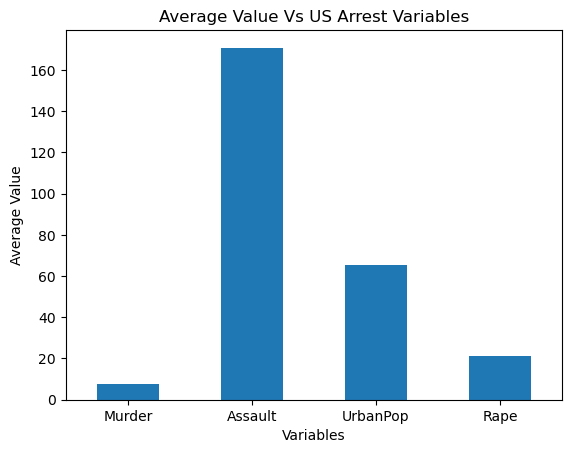

In [28]:
#A bar chart to visualize the average values of the variables in the USArrests dataset
arrests_df[['Murder','Assault','UrbanPop','Rape']].mean().plot(kind='bar')
plt.xlabel('Variables')
plt.ylabel('Average Value')
plt.title('Average Value Vs US Arrest Variables')
plt.xticks(rotation=0)
plt.show()


## PREPROCESSING AND MODELLING FOR WINE DATASET

In [29]:
#Wine Dataset
#Identifying numerical and categorical columns

numerical_wine = X_wine.select_dtypes(include=['int64','float64']).columns
categorical_wine = X_wine.select_dtypes(include=['object','category']).columns
print("Numerical_wine:",list(numerical_wine))
print("Categorical_wine:",list(categorical_wine))

Numerical_wine: ['Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols', 'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue', 'OD', 'Proline']
Categorical_wine: []


In [30]:
#Splitting Data
X_train_wine,X_test_wine,y_train_wine,y_test_wine = train_test_split(
    X_wine,
    y_wine,
    test_size = 0.2,
    random_state=42,
    stratify=y_wine
)

In [31]:
#Preprocess numerical variables
#Since wine is numerical we use Standardscaler

scaler_wine = StandardScaler()
X_train_scaled = scaler_wine.fit_transform(X_train_wine)
X_test_wine_scaled = scaler_wine.transform(X_test_wine)

## PREPROCESSING AND MODELLING FOR CHICKWTS DATASET

In [32]:
#Chickwits Dataset
#identify numerical and categorical columns

numerical_chick = chickwts_df.select_dtypes(include=['int64','float64']).columns
categorical_chick = chickwts_df.select_dtypes(include=['object','category']).columns

print("Numerical Chick:",list(numerical_chick))
print("Categorical Chick:",list(categorical_chick))

Numerical Chick: ['rownames', 'weight']
Categorical Chick: ['feed']


## PREPROCESSING AND MODELLING USArrest DATASET

In [33]:
numerical_arrests = arrests_df.select_dtypes(include=['int64','float64']).columns
categorical_arrests = arrests_df.select_dtypes(include=['object','category']).columns

print("Numerical Arrests:",list(numerical_arrests))
print("Categorical_Arrests:",list(categorical_arrests))

Numerical Arrests: ['Murder', 'Assault', 'UrbanPop', 'Rape']
Categorical_Arrests: ['State']


In [34]:
X_arrests = arrests_df[['Murder','Assault','UrbanPop','Rape']]

In [35]:
X_arrests.isnull().sum()

Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

In [36]:
arrests_df.columns

Index(['Murder', 'Assault', 'UrbanPop', 'Rape', 'State'], dtype='object')

In [37]:
# Standardize USArrests Data
scaler_arrests = StandardScaler()

arrests_scaled = scaler_arrests.fit_transform(
    arrests_df.iloc[:, :-1]
)

print(arrests_df.iloc[:, :-1].columns)



Index(['Murder', 'Assault', 'UrbanPop', 'Rape'], dtype='object')


In [38]:
import warnings
warnings.filterwarnings('ignore')

In [39]:
#Feature Selection
selector = SelectKBest(score_func=f_classif, k=3)
arrests_selected = selector.fit_transform(arrests_scaled, arrests_df.index)


In [40]:
#Apply PCA
pca = PCA(n_components=2)
arrests_pca = pca.fit_transform(arrests_selected)

In [41]:
# Hyperparameter Tuning for K-Means 
# Finding the best number of clusters
inertia = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(arrests_pca)
    inertia.append(kmeans.inertia_)

best_k = inertia.index(min(inertia [1:]))+1


In [42]:
# Apply K-Means Clustering
kmeans = KMeans(n_clusters=best_k, random_state=42)
arrests_df['KMeans_Cluster'] = kmeans.fit_predict(arrests_pca)

In [43]:
# Hyperparameter Tuning for Gaussian Mixture Model (GMM)
best_gmm_k = 1
lowest_bic = np.inf
for k in range(1, 11):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(arrests_pca)
    bic = gmm.bic(arrests_pca)
    if bic < lowest_bic:
        lowest_bic = bic
        best_gmm_k = k


In [44]:
# Apply Gaussian Mixture Model (GMM) Clustering
gmm = GaussianMixture(n_components=best_gmm_k, random_state=42)
arrests_df['GMM_Cluster'] = gmm.fit_predict(arrests_pca)

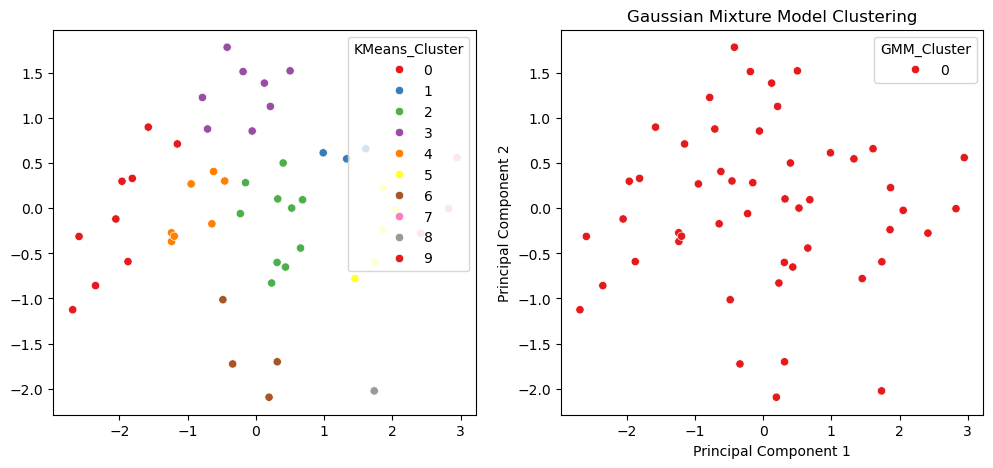

Bestnumber of clusters for K-Means: 10
Best number of components for GMM: 1


In [45]:
# Visualize the clustering results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

sns.scatterplot(
    x=arrests_pca[:, 0],
    y=arrests_pca[:, 1],
    hue=arrests_df['KMeans_Cluster'],
    palette='Set1',
    legend='full'
)

plt.subplot(1, 2, 2)
sns.scatterplot(
    x=arrests_pca[:, 0],
    y=arrests_pca[:, 1],
    hue=arrests_df['GMM_Cluster'],
    palette='Set1',
    legend='full'
)

plt.title('Gaussian Mixture Model Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Print the best number of clusters for K-Means and GMM
print(f"Bestnumber of clusters for K-Means: {best_k}")
print(f"Best number of components for GMM: {best_gmm_k}")


**K-Means clustering with Gaussian Mixture Model (GMM) clustering after reducing the data to two principal components using PCA.**

- K-Means (left): The data is divided into 10 distinct clusters, shown by different colors.

The clusters appear to form relatively compact groups in the PCA space.


- GMM (right): All observations are assigned to one cluster (Cluster 0), as indicated by the single color in the legend.


*K-Means* identifies meaningful groupings, while the *GMM* result shown does not distinguish between groups.


Seemingly, K-Means provides much more informative segmentation of the observations than the GMM model in this analysis.
